# Evaluación de clasificadores . Derecho a las Víctimas

## ¿Qué hace este notebook?

Compara las predicciones de cualquier clasificador contra las etiquetas reales del test set y muestra:

- Métricas principales (Accuracy, F1, Precision, Recall, Kappa)
- Matriz de confusión
- Análisis de errores 

**Para evaluar un clasificador nuevo:** se cambian las rutas en la Sección 1 y se corren todas las celdas 


### Nota sobre las métricas

La métrica principal es **F1 macro**, no Accuracy, porque las clases están desbalanceadas (más negativos que positivos). Además para Kappa el criterio es el siguiente:

| Kappa     | Interpretación   |
| < 0.0     | Peor que el azar |
| 0.0 – 0.2 | Leve             |
| 0.2 – 0.4 | Débil            |
| 0.4 – 0.6 | Moderado         |
| 0.6 – 0.8 | Bueno            | 
| > 0.8     | Excelente        |

> **Observación:** los falsos negativos (predijo NO, era SÍ) son más costosos que los falsos positivos en este dominio, porque perder una norma de derechos de víctimas es peor que incluir una de más.

## 1. Configuración

**Solo modificar esta sección para evaluar un clasificador nuevo.**

In [42]:
#  Archivo con las predicciones del clasificador a evaluar 
# Debe tener columnas: 'Número' y 'caso_ok' (la predicción)
# Opcionalmente: 'Justificación' para el análisis de errores
FILE_PREDICCIONES  = 'resultado_gemini_texto_completo2.xlsx'

# Nombre del clasificador (aparece en los gráficos y tablas)
NOMBRE_CLASIFICADOR = 'Gemini Colab con texto completo'

# Archivo original con las etiquetas reales
FILE_ORIGINAL = 'Normativa_nacional_con_texto.xlsx'

#Archivo test con las etiquetas originales 
FILE_TEST_ETIQUETAS =  'test_con_etiqueta.xlsx'

# Parámetros del split
TEST_SIZE    = 0.30
RANDOM_STATE = 42

## 2. Imports

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score,
    recall_score, cohen_kappa_score
)
from sklearn.model_selection import train_test_split
from IPython.display import display

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})


## 3. Carga y merge de datos

In [44]:
df_pred = pd.read_excel(FILE_PREDICCIONES)
df_test = pd.read_excel(FILE_TEST_ETIQUETAS)
df_pred['Número'] = df_pred['Número'].astype(str).str.strip()
df_test['Número'] = df_test['Número'].astype(str).str.strip()

merged = df_pred.merge(
    df_test[['Número', 'caso_ok']],
    on='Número',
    suffixes=('_pred', '_real')
)
merged = merged[merged['caso_ok_pred'] != -1]
n = len(merged)

y_pred = merged['caso_ok_pred']
y_real = merged['caso_ok_real']

## 4. Métricas

In [45]:
# Tabla de métricas
metricas = {
    'Accuracy':              round(accuracy_score(y_real, y_pred), 3),
    'F1 macro':            round(f1_score(y_real, y_pred, average='macro'), 3),
    'F1 positivos (SÍ)':     round(f1_score(y_real, y_pred, pos_label=1), 3),
    'F1 negativos (NO)':     round(f1_score(y_real, y_pred, pos_label=0), 3),
    'Precision positivos':   round(precision_score(y_real, y_pred, pos_label=1), 3),
    'Recall positivos':      round(recall_score(y_real, y_pred, pos_label=1), 3),
    'Kappa':                 round(cohen_kappa_score(y_real, y_pred), 3),
}

df_metricas = pd.DataFrame(
    metricas.items(), columns=['Métrica', 'Valor']
).set_index('Métrica')

print(f'Clasificador: {NOMBRE_CLASIFICADOR}')
print()
display(
    df_metricas.style
    .format('{:.3f}')
    .background_gradient(cmap='RdYlGn', vmin=0, vmax=1, axis=0)
    .set_caption(f'Métricas — {NOMBRE_CLASIFICADOR}')
)

Clasificador: Gemini Colab con texto completo



,Valor
Métrica,
Accuracy,0.661
F1 macro,0.657
F1 positivos (SÍ),0.618
F1 negativos (NO),0.696
Precision positivos,0.531
Recall positivos,0.739
Kappa,0.328


In [46]:
# ── Reporte detallado por clase ───────────────────────────────────────────────
print(classification_report(
    y_real, y_pred,
    labels=[0, 1],
    target_names=['NO víctima (0)', 'SÍ víctima (1)'],
    zero_division=0
))

                precision    recall  f1-score   support

NO víctima (0)       0.80      0.62      0.70        39
SÍ víctima (1)       0.53      0.74      0.62        23

      accuracy                           0.66        62
     macro avg       0.67      0.68      0.66        62
  weighted avg       0.70      0.66      0.67        62



## 5. Matriz de confusión

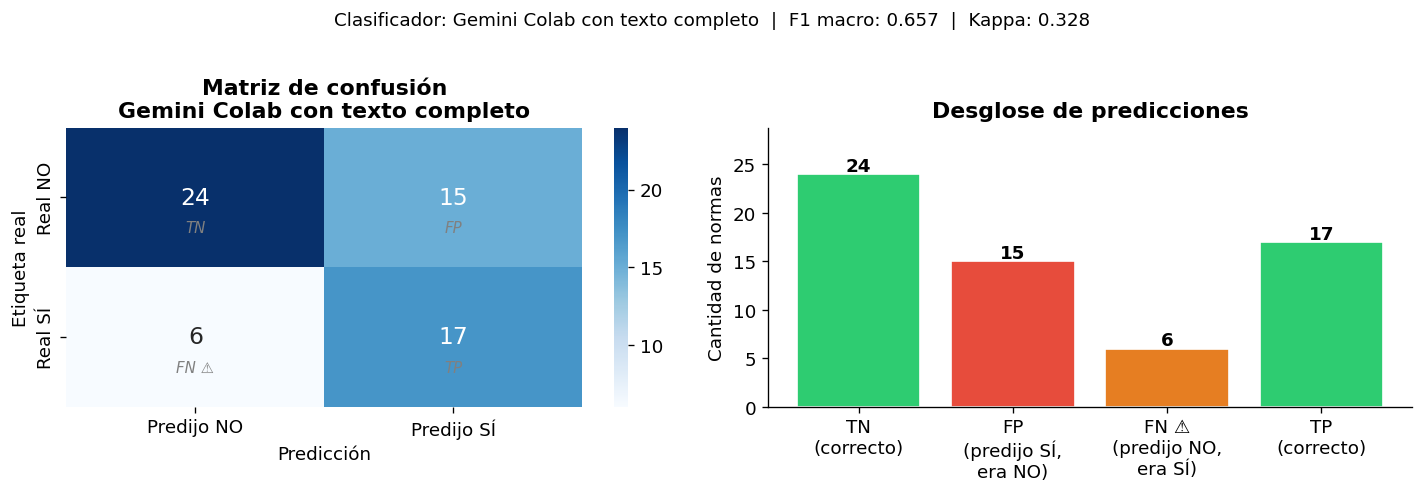

TN=24  FP=15  FN=6  TP=17
Total correctos: 41/62 (66.1%)
Total errores:   21/62 (33.9%)


In [47]:
cm = confusion_matrix(y_real, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=['Predijo NO', 'Predijo SÍ'],
    yticklabels=['Real NO', 'Real SÍ'],
    annot_kws={'size': 14}
)
ax.set_title(f'Matriz de confusión\n{NOMBRE_CLASIFICADOR}', fontweight='bold')
ax.set_ylabel('Etiqueta real')
ax.set_xlabel('Predicción')
for (i, j), label in [((0,0),'TN'), ((0,1),'FP'), ((1,0),'FN ⚠'), ((1,1),'TP')]:
    ax.text(j+0.5, i+0.75, label, ha='center', fontsize=9, color='gray', style='italic')


ax2 = axes[1]
categorias = ['TN\n(correcto)', 'FP\n(predijo SÍ,\nera NO)', 'FN ⚠\n(predijo NO,\nera SÍ)', 'TP\n(correcto)']
valores    = [tn, fp, fn, tp]
colores    = ['#2ecc71', '#e74c3c', '#e67e22', '#2ecc71']
bars = ax2.bar(categorias, valores, color=colores, edgecolor='white')
for bar, val in zip(bars, valores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', fontweight='bold')
ax2.set_title('Desglose de predicciones', fontweight='bold')
ax2.set_ylabel('Cantidad de normas')
ax2.set_ylim(0, max(valores) * 1.2)

n = len(merged)
plt.suptitle(f'Clasificador: {NOMBRE_CLASIFICADOR}  |  F1 macro: {metricas["F1 macro"]:.3f}  |  Kappa: {metricas["Kappa"]:.3f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'Total correctos: {tn+tp}/{n} ({(tn+tp)/n:.1%})')
print(f'Total errores:   {fp+fn}/{n} ({(fp+fn)/n:.1%})')

## 6. Análisis de errores

Se muestran primero los **falsos negativos** (predijo NO, era SÍ) porque son más costosos.

In [48]:
errores = merged[merged['caso_ok_pred'] != merged['caso_ok_real']].copy()
errores['tipo_error'] = errores.apply(
    lambda r: 'FN — predijo NO, era SÍ' if r['caso_ok_pred'] == 0
              else 'FP — predijo SÍ, era NO',
    axis=1
)

print(f'Total errores: {len(errores)} de {n} ({len(errores)/n:.1%})')
print(errores['tipo_error'].value_counts().to_string())

Total errores: 21 de 62 (33.9%)
tipo_error
FP — predijo SÍ, era NO    15
FN — predijo NO, era SÍ     6


In [49]:
# ── Falsos negativos ──────────────────────────────────────────────────────────
fn_df = errores[errores['tipo_error'] == 'FN — predijo NO, era SÍ']

print(f'⚠️  Falsos negativos: {len(fn_df)} casos')
print('(El clasificador dijo NO pero la etiqueta real era SÍ)')
print()

cols = ['Número', 'Título'] if 'Título' in fn_df.columns else ['Número']
if 'Justificación' in fn_df.columns:
    cols.append('Justificación')

pd.set_option('display.max_colwidth', 80)
display(fn_df[cols].reset_index(drop=True))

⚠️  Falsos negativos: 6 casos
(El clasificador dijo NO pero la etiqueta real era SÍ)



,Número,Título,Justificación
0,5209,EMERGENCIA PéBLICA,"0: El resumen menciona ""víctimas"" en el contexto de una emergencia pública y..."
1,18577,RELACIONES INTERNACIONALES,0: La norma se refiere a la venta de trigo a la Santa Sede para asistir a ví...
2,888,DUELO NACIONAL,"0: La norma declara duelo nacional en homenaje a las víctimas, pero no estab..."
3,840,DUELO NACIONAL,"0: La norma declara duelo nacional en homenaje a las víctimas, pero no estab..."
4,490,MONUMENTOS NACIONALES,0: La norma decreta la creación de un monumento conmemorativo y no establece...
5,787,ATENTADOS EMBAJADA DE ISRAEL Y AMIA,0: La norma autoriza el acceso a información para la investigación de atenta...


In [50]:
# ── Falsos positivos ──────────────────────────────────────────────────────────
fp_df = errores[errores['tipo_error'] == 'FP — predijo SÍ, era NO']

print(f'Falsos positivos: {len(fp_df)} casos')
print('(El clasificador dijo SÍ pero la etiqueta real era NO)')
print()

cols = ['Número', 'Título'] if 'Título' in fp_df.columns else ['Número']
if 'Justificación' in fp_df.columns:
    cols.append('Justificación')

display(fp_df[cols].reset_index(drop=True))

Falsos positivos: 15 casos
(El clasificador dijo SÍ pero la etiqueta real era NO)



,Número,Título,Justificación
0,25632,CONVENCIONES,"1: La norma aprueba una convención que establece mecanismos para prevenir, r..."
1,844,FONDO DE ASISTENCIA DIRECTA A VICTIMAS DE TRATA,1: La norma aprueba la reglamentación de un fondo para la asistencia directa...
2,21507,FUERZAS ARMADAS Y DE SEGURIDAD,1: La norma establece un subsidio extraordinario para el personal militar y ...
3,235,PROTECCION CONTRA LA VIOLENCIA FAMILIAR,"1: La norma establece mecanismos de información, asesoramiento y registro de..."
4,26378,CONVENCIONES,1: La norma aprueba una convención que establece derechos para personas con ...
5,26842,PREVENCION Y SANCION DE LA TRATA DE PERSONAS Y ASISTENCIA A SUS VICTIMAS,1: La norma establece explícitamente derechos para las víctimas de trata de ...
6,27508,FONDO FIDUCIARIO PUBLICO,1: La norma crea un fondo fiduciario para la asistencia directa a víctimas d...
7,26827,DERECHOS HUMANOS,1: La norma establece un sistema para prevenir la tortura y otros tratos cru...
8,27402,ACUERDOS,1: La norma aprueba un acuerdo que incluye la asistencia y protección de las...
9,23466,PENSIONES,"1: La norma otorga una pensión a familiares de personas desaparecidas, benef..."


## 7. Comparación entre clasificadores (opcional)

Correr esta celda después de evaluar múltiples clasificadores para comparar sus métricas.

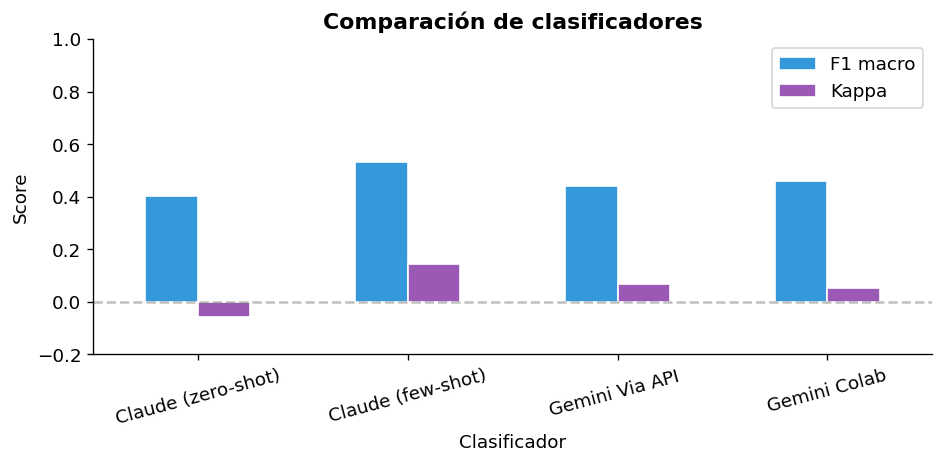

,F1 macro,Kappa
Clasificador,,
Claude (zero-shot),0.402,-0.057
Claude (few-shot),0.531,0.143
Gemini Via API,0.441,0.068
Gemini Colab,0.461,0.054


In [51]:
# Completar con los resultados de cada clasificador evaluado
# Copiar los valores de F1 macro y Kappa de cada ejecución anterior

resultados = [
    {'Clasificador': 'Claude (zero-shot)', 'F1 macro': 0.402, 'Kappa': -0.057},
    {'Clasificador': 'Claude (few-shot)', 'F1 macro':0.531 , 'Kappa': 0.143},
    {'Clasificador': 'Gemini Via API ',     'F1 macro': 0.441, 'Kappa': 0.068},
    {'Clasificador': 'Gemini Colab',    'F1 macro': 0.461, 'Kappa': 0.054},
]

if not resultados:
    print('Todavía no hay resultados para comparar. Completar la lista de arriba.')
else:
    df_comp = pd.DataFrame(resultados).set_index('Clasificador')

    ax = df_comp.plot(
        kind='bar', figsize=(8, 4),
        color=['#3498db', '#9b59b6'],
        edgecolor='white'
    )
    ax.set_title('Comparación de clasificadores', fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim(-0.2, 1)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=15)
    ax.legend()
    plt.tight_layout()
    plt.show()

    display(df_comp)